In [1]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
nltk.download('punkt')
from nltk.tokenize import word_tokenize
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
ds = load_dataset("webis/tldr-17", split="train")

README.md: 0.00B [00:00, ?B/s]

tldr-17.py: 0.00B [00:00, ?B/s]

dataset_infos.json: 0.00B [00:00, ?B/s]

The repository for webis/tldr-17 contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/webis/tldr-17.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N]  y


corpus-webis-tldr-17.zip:   0%|          | 0.00/3.14G [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3848330 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/38 [00:00<?, ?it/s]

In [4]:
df = ds.to_pandas()
df = df[['subreddit', 'body', 'content']].dropna()
df

,subreddit,body,content
0,math,I think it should be fixed on either UTC stand...,I think it should be fixed on either UTC stand...
1,funny,Art is about the hardest thing to categorize i...,Art is about the hardest thing to categorize i...
2,Borderlands,Ask me what I think about the Wall Street Jour...,Ask me what I think about the Wall Street Jour...
3,gamingpc,"In Mechwarrior Online, I have begun to use a m...","In Mechwarrior Online, I have begun to use a m..."
4,Diablo,"You are talking about the Charsi imbue, right?...","You are talking about the Charsi imbue, right?..."
...,...,...,...
3848325,sex,I've finally gotten around to initiating plans...,I've finally gotten around to initiating plans...
3848326,AskReddit,"Long time lurker, first time poster here. I'm ...","Long time lurker, first time poster here. I'm ..."
3848327,AskReddit,"Long time lurker, first time poster here. I'm ...","Long time lurker, first time poster here. I'm ..."
3848328,battlefield3,My xbox hasn't been in the best of health rece...,My xbox hasn't been in the best of health rece...


In [5]:
# Define target game subreddits
game_subreddits = ['leagueoflegends', 'pokemon', 'zelda', 'Overwatch', 'smashbros', 'hearthstone']

# Filter the DataFrame
df_games = df[df['subreddit'].isin(game_subreddits)].copy()

print(df_games['subreddit'].value_counts())

subreddit
leagueoflegends    109307
hearthstone          9500
pokemon              6464
smashbros            4464
Overwatch            3633
zelda                1182
Name: count, dtype: int64


## Preprocessing

Firstly, we used the content text that doesn't include TL;DR part because it could bias the phrase extraction towards words that are common in summaries. Summaries often repeat key points in a condensed way rather than reflecting the natural flow of the document. 

We aimed to extract distinct phrases for each subreddit using a TF-IDF model. To improve the quality of the results, we first removed elements that are not useful for our task, such as links and stop words. In addition to stop words, we noticed that some phrases still appeared as important — for example, phrases like “quick play”, “ranked games”, or “playing overwatch”. To address this, we also removed certain domain-related words like “play”, “playing”, “game”, as well as the names of the games themselves, like "pokemon", "zelda", and "smash" etc., so that phrases containing these words would not dominate the results. Finally, we applied stemming to normalize word forms and avoid treating different surface forms of the same concept as distinct phrases.

Note: I did not apply stemming for TF-IDF because the Word2Vec model was trained on original (unstemmed) words. Stemming TF-IDF phrases created tokens that don’t match Word2Vec’s vocabulary, making it hard to retrieve embeddings or find similar words. Keeping original word forms ensures consistency between TF-IDF phrases and Word2Vec embeddings. That’s why our TF-IDF phrases may look a bit messy, but they work well for matching with the Word2Vec embeddings.

In [6]:
common_words = {"game", "games", "gaming", "player", "play", "playing", "plays", "pokemon", "zelda", "smash", "smashbros" "overwatch", "hearthstone", "legends"}
    
def preprocess(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text) #removes links if any
    text = re.sub(r'[^a-z\s]', ' ', text) #replaces anything that is not a letter or space with a space
    text = re.sub(r'\s+', ' ', text).strip() #replace multiple whitespace characters with a single space
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words and word not in common_words]
    return " ".join(tokens)

# Apply to the filtered gaming dataset
df_games['cleaned_body'] = df_games['content'].apply(preprocess)

In [7]:
df_games[['subreddit', 'body', 'cleaned_body']].head()

,subreddit,body,cleaned_body
15,leagueoflegends,Didn't they lose 6 games in a row? Just becaus...,lose row close mean lot weaker team love arkan...
64,leagueoflegends,Because spinning axe is a massive damage buff(...,spinning axe massive damage buff percent based...
106,zelda,My thoughts from nine months ago and its corre...,thoughts nine months ago corresponding discuss...
123,leagueoflegends,"I agree, and feel like TRM...may or may not ge...",agree feel like trm may may get lot unnecessar...
124,leagueoflegends,I kinda of have issue with putting blame on ju...,kinda issue putting blame one party yes agree ...


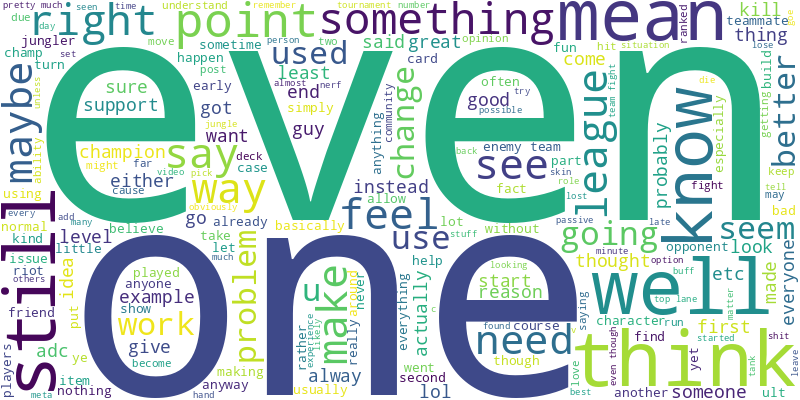

In [8]:
# quickly identify the word's frequencies
from wordcloud import WordCloud

# Join all cleaned text
all_text = " ".join(df_games['cleaned_body'])

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

wordcloud.to_image()

In [9]:
# Group posts by subreddit and concatenate all texts
grouped = df_games.groupby('subreddit')['cleaned_body'].apply(lambda texts: ' '.join(texts)).reset_index()

We want to identify which bigrams are most characteristic of each subreddit. To do this, we compute the importance of specific bigrams (2-word phrases) for each subreddit using TF-IDF. We also experimented with extracting both unigrams and bigrams, but the results were mostly dominated by character names and failed to capture game-specific concepts or meaningful semantic clusters.

In [10]:
# Create the vectorizer
vectorizer = TfidfVectorizer(ngram_range=(2,2), max_df=0.6, use_idf=True)  #max_df: ignores bigrams that appear in more than 60% of documents

# Fit and transform
tfidf_matrix = vectorizer.fit_transform(grouped['cleaned_body'])

# Convert to DataFrame
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), index=grouped['subreddit'], columns=vectorizer.get_feature_names_out())

In [11]:
tfidf_df

,aa aa,aa ab,aa abilities,aa ability,aa able,aa abuse,aa activated,aa activating,aa active,aa actually,...,zzzzzzz fuck,zzzzzzz lock,zzzzzzz shit,zzzzzzzz deven,zzzzzzzz seen,zzzzzzzzzzz annoying,zzzzzzzzzzz guys,zzzzzzzzzzz jarvan,zzzzzzzzzzzzzz friends,zzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzz amourious
subreddit,,,,,,,,,,,,,,,,,,,,,
Overwatch,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
hearthstone,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
leagueoflegends,0.012194,0.000061,0.000368,0.00049,0.000123,0.000061,0.000061,0.000061,0.000245,0.000245,...,0.000061,0.000061,0.000061,0.000061,0.000061,0.000061,0.000061,0.000061,0.000061,0.000061
pokemon,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
smashbros,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
zelda,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


There are some unusual bigrams that probably appear only in the League of Legends data, so their TF-IDF scores are non-zero there. All other subreddits lack these bigrams, resulting in TF-IDF scores of zero for those phrases. However, we assume these rare bigrams won’t significantly affect the results. We set max_df = 0.6 to ignore terms that appear in more than 60% of the documents. Such terms are considered too common and are excluded from the vocabulary.

 The higher the score, the more unique and important that bigram is for that subreddit.

In [12]:
# Get top N unique terms
top_n = 20
for subreddit in tfidf_df.index:
    print(f"\n -Top {top_n} terms for r/{subreddit}:")
    top_terms = tfidf_df.loc[subreddit].sort_values(ascending=False).head(top_n)
    print(top_terms)


 -Top 20 terms for r/Overwatch:
loot boxes          0.141670
skill rating        0.098433
torbj rn            0.086382
mercy lucio         0.086382
gold medals         0.082794
reinhardt shield    0.080773
capture point       0.079114
tracer genji        0.078529
attacking team      0.078194
team comp           0.077667
defense matrix      0.076286
discord orb         0.070676
loot box            0.069555
overwatch team      0.067311
fan hammer          0.067311
team composition    0.065240
lucio mercy         0.065067
like tracer         0.062824
left click          0.059804
tracer reaper       0.056092
Name: Overwatch, dtype: float64

 -Top 20 terms for r/hearthstone:
hero power         0.218500
control warrior    0.187971
dr boom            0.171297
card draw          0.170534
next turn          0.155244
board control      0.145845
face hunter        0.142634
control decks      0.129731
aggro decks        0.124398
cards like         0.120718
freeze mage        0.112294
miracle rogu

In [13]:
# !Run this if you want to see the top 50 phrases for each subreddit
top_phrases = []

for subreddit, row in tfidf_df.iterrows():
    top = row.sort_values(ascending=False).head(50)
    for phrase, score in top.items():
        top_phrases.append({'subreddit': subreddit, 'phrase': phrase, 'tfidf_score': score})

top_50_df = pd.DataFrame(top_phrases)
top_50_df.to_csv('top_50_phrases_per_subreddit.csv', index=False)

## -Collect Gensim's Phrases-

We used Gensim’s Phrases model to identify phrases:

- It automatically detects collocations based on their co-occurrence frequencies and statistical association

- Learns phrases that appear together significantly more than chance

In [14]:
#FOR WORD2VEC
#Tokenize the cleaned body
tokenized_docs = df_games['cleaned_body'].apply(str.split).tolist()
print(tokenized_docs[0][:20])

['lose', 'row', 'close', 'mean', 'lot', 'weaker', 'team', 'love', 'arkansas', 'razorbacks', 'football', 'years', 'think', 'lost', 'alabama', 'lsu', 'field', 'goal', 'missed', 'less']


In [15]:
from gensim.models import Phrases
from gensim.models.phrases import Phraser

#Train a Phrases model on tokenized_docs

# Detect frequent bigrams
phrases = Phrases(tokenized_docs, min_count=5, threshold=10)
bigram_model = Phraser(phrases) #bigrams are joined (wind_waker)

# Apply the model to tokenized text
corpus_phrased = [bigram_model[doc] for doc in tokenized_docs]

print(corpus_phrased[0][:50])  # it doesn’t have phrases that meet the criteria
print(corpus_phrased[1][:50])  # see the detected bigrams merged with underscores

['lose', 'row', 'close', 'mean', 'lot', 'weaker', 'team', 'love', 'arkansas', 'razorbacks', 'football', 'years', 'think', 'lost', 'alabama', 'lsu', 'field', 'goal', 'missed', 'less', 'yards', 'year', 'lost', 'alabam', 'team', 'isnt', 'young', 'ranked', 'quarterback', 'get', 'injured', 'ul', 'monroe', 'make', 'points']
['spinning_axe', 'massive', 'damage', 'buff', 'percent', 'based', 'damage', 'buff', 'applies', 'passive', 'dot', 'even', 'rank', 'one', 'use', 'spell', 'keep', 'buff', 'extended', 'amount', 'time', 'even', 'apply', 'asking', 'massive', 'damage', 'increase', 'countered', 'expire', 'set', 'time', 'like', 'asking', 'corki_rockets', 'home', 'nearest', 'low', 'heath', 'champion', 'deal', 'true_damage']


We used Gensim’s Phrases model to multi-word expressions like "wind waker" or "spinning axe" and treat them as single tokens like wind_waker or spinning_axe.

## Training Word2Vec

- The Word2Vec model was trained on this phrased corpus (corpus_phrased), where common multi-word expressions were merged with underscores.

- We used the skip-gram architecture to learn embeddings that predict surrounding context words.

- The model had an embedding size of 100 dimensions, a window size of 5, ignored tokens that appeared fewer than 5 times, and was trained for 10 epochs.

In [16]:
from gensim.models import Word2Vec
from gensim.models.callbacks import CallbackAny2Vec
from tqdm import tqdm

class EpochLogger(CallbackAny2Vec):
    def __init__(self, epochs):
        self.epochs = epochs
        self.pbar = tqdm(total=epochs, desc='Training Epochs')
    
    def on_epoch_end(self, model):
        self.pbar.update(1)
    
    def on_train_end(self, model):
        self.pbar.close()

# Then train the model with the callback

epoch_logger = EpochLogger(epochs=10)

w2v_model = Word2Vec(
    sentences=corpus_phrased,
    vector_size=100,   # Embedding dimensions
    window=5,    # Context window
    min_count=5,  # Ignore rare words
    sg=1,    # Use skip-gram (1) or CBOW (0)
    workers=4,
    epochs=10, # increase this for better training (epochs = 10)
    callbacks=[epoch_logger]
)

Training Epochs: 100%|██████████| 10/10 [07:15<00:00, 43.51s/it]


In [17]:
# Save the whole model
w2v_model.save("subreddit_bigrams_word2vec.model")

# Optionally:save just the vectors
#w2v_model.wv.save_word2vec_format("subreddit_bigrams_vectors.txt")

For each subreddit, we identified the top 20 most distinctive phrases (those with the highest TF-IDF scores).
These phrases were collected into a set, merged with underscores, and converted to the same format (e.g., wind waker - wind_waker), since the Word2Vec model was trained on text where frequent phrases were joined with underscores.

In [18]:
# Initialize an empty set to avoid duplicates
unique_phrases = set()

# Collect top 20 TF-IDF phrases for each subreddit
top_n = 20
for subreddit in tfidf_df.index:
    top_terms = tfidf_df.loc[subreddit].sort_values(ascending=False).head(top_n)
    unique_phrases.update(top_terms.index)

# Convert set to list
unique_phrases = list(unique_phrases)

# Convert phrases to gensim format (with underscores)
unique_phrases = [phrase.replace(" ", "_") for phrase in unique_phrases]

In [19]:
#See the most 20 similar words/phrases
for phrase in unique_phrases:
    try:
        similar = w2v_model.wv.most_similar(phrase, topn=20)
        print(f"\n Phrase: {phrase}")
        for word, score in similar:
            print(f"    {word} (score: {score:.3f})")
    except KeyError:
        print(f"\nPhrase '{phrase}' not in Word2Vec vocabulary.")


 Phrase: torbj_rn
    tjorborn (score: 0.755)
    widowmaker_hanzo (score: 0.754)
    bastion (score: 0.754)
    mccree_pharah (score: 0.746)
    symmetra (score: 0.736)
    torbjorn_symmetra (score: 0.718)
    zenyatta (score: 0.718)
    hanzo_widowmaker (score: 0.716)
    defense_heroes (score: 0.712)
    reinhardt_shield (score: 0.712)
    pharah_junkrat (score: 0.709)
    torb (score: 0.708)
    symettra (score: 0.705)
    torbjorn (score: 0.703)
    torby (score: 0.702)
    pharah_widow (score: 0.701)
    bastion_mei (score: 0.701)
    bastion_bastion (score: 0.700)
    reinhardt_winston (score: 0.700)
    toblerone (score: 0.700)

 Phrase: mercy_lucio
    lucio_mercy (score: 0.832)
    healers (score: 0.815)
    reinhardt_zarya (score: 0.802)
    lucio_zenyatta (score: 0.797)
    symmetra_defense (score: 0.789)
    l_cio (score: 0.786)
    offense_heroes (score: 0.785)
    zenyatta (score: 0.784)
    defense_heroes (score: 0.777)
    mercy (score: 0.769)
    lucio (score: 0.766)

We extracted the 20 nearest neighbors determined by cosine similarity in vector space to chosen phrase. The results reflect how phrases are used in context across communities, offering insight into their meanings and associations in gaming discourse.

For example:

Skull Kid: A child-like character who lives in the "lost woods" and carries a sword as a weapon.

Majora's Mask: A powerful and evil mask that the Skull Kid steals from the Happy Mask Salesman.

Happy Mask Salesman: A mysterious character who travels the land selling and collecting masks. He is the original owner of Majora's Mask.

The Skull Kid, under the influence of Majora's Mask, becomes the main antagonist, causing chaos and attempting to destroy Termina. The Happy Mask Salesman's primary goal is to recover Majora's Mask, which he considers dangerous to be left in the wrong hands.
Skull Kid was originally part of the "Kokiri" world but became corrupted by Majora’s Mask, causing him to cause chaos and separate from the Kokiri.

## PCA

Since the embeddings are high-dimensional, we applied Principal Component Analysis (PCA) to reduce them to 2 dimensions (X_reduced) for visualization.

In [20]:
import numpy as np
import plotly.express as px
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import pandas as pd
import plotly.io as pio

In [21]:
# Filter to only those in the vocab
valid_phrases = [p for p in unique_phrases if p in w2v_model.wv]

# Get their vectors
X = np.array([w2v_model.wv[p] for p in valid_phrases])

# Reduce to 2D
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)

# Set Plotly renderer
pio.renderers.default = 'notebook'

# Check data availability
#print(X_reduced.shape)
#print(valid_phrases)

# Create a DataFrame for Plotly
pca_df = pd.DataFrame({
    'x': X_reduced[:, 0],
    'y': X_reduced[:, 1],
    'phrase': valid_phrases
})

# Create interactive scatter plot
fig = px.scatter(
    pca_df, 
    x='x', 
    y='y', 
    text='phrase', #if this commented out, no text will show unless mouseover
    #hover_name='phrase',  # Show phrase on hover
    hover_data=['phrase'],  # Shows phrase on hover
    title="Interactive 2D PCA Visualization of Subreddit Bigrams"
)

# Adjust text position and size
fig.update_traces(
    textposition='top center',
    textfont_size=10,
    marker=dict(size=8)
)

# Add axis labels
fig.update_layout(
    xaxis_title="PCA 1",
    yaxis_title="PCA 2",
    hovermode='closest'
)

# Show the figure
fig.show(renderer='iframe')

Phrases that appear close together likely have similar meanings or occur in similar contexts in subreddit data.

Phrases that are far apart are less related in terms of usage/context.

Since TfidfVectorizer was set to ngram_range=(2, 2), it only considered bigrams. As a result, all the top terms I extracted were bigrams in PCA. 

## K-Means Clustering

KMeans groups phrases with similar vector representations.

- The model tries to group together bigrams that appeared in similar contexts across the data. For example, phrases about a particular game or character might cluster together because their usage patterns are similar.

- Each cluster may represent a different topic  (e.g., one cluster's tokens could be related to Overwatch, another to Pokémon, etc.).

In [22]:
n_clusters = 6  # adjust this
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
labels = kmeans.fit_predict(X)

# Create DataFrame for plotting
pca_cluster_df = pd.DataFrame({
    'x': X_reduced[:, 0],
    'y': X_reduced[:, 1],
    'phrase': valid_phrases,
    'cluster': labels.astype(str)  # Convert to string for nicer labels
})

# Plotly scatter plot
fig = px.scatter(
    pca_cluster_df,
    x='x',
    y='y',
    color='cluster',
    text='phrase',
    hover_data=['phrase'],
    title="Interactive PCA + KMeans Clustering of Subreddit Bigrams",
    color_discrete_sequence=px.colors.qualitative.Safe  # or other color set
)

# Tweak marker and text appearance
fig.update_traces(
    textposition='top center',
    textfont_size=10,
    marker=dict(size=8, line=dict(width=0.5, color='black'))
)

# Axis labels and layout
fig.update_layout(
    xaxis_title="PCA 1",
    yaxis_title="PCA 2",
    hovermode='closest',
    legend_title="Cluster"
)

# Show the plot
fig.show(renderer='iframe')

/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning



## PCA with Similar Word2vec embeddings

We want to see the distribution of each phrase in vector space along with their similar meanings, as included below.

In [23]:
# TF-IDF phrases
all_terms = set(unique_phrases)

# For each, add its top similar terms
for phrase in unique_phrases:
    if phrase in w2v_model.wv:
        similar_terms = w2v_model.wv.most_similar(phrase, topn=20)
        for word, _ in similar_terms:
            all_terms.add(word)

# Convert to list
all_terms = list(all_terms)

# Filter to those in vocab
valid_terms = [t for t in all_terms if t in w2v_model.wv]

# Get vectors
X = np.array([w2v_model.wv[t] for t in valid_terms])

# PCA
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)

# Set Plotly renderer
pio.renderers.default = 'notebook'

# Create a DataFrame for Plotly
pca_df_word2vec = pd.DataFrame({
    'x': X_reduced[:, 0],
    'y': X_reduced[:, 1],
    'phrase': valid_terms
})

# Create interactive scatter plot
fig = px.scatter(
    pca_df_word2vec, 
    x='x', 
    y='y', 
    #text='phrase', #if this commented out, no text will show unless mouseover
    #hover_name='phrase',  # Show phrase on hover
    hover_data=['phrase'],  # Shows phrase on hover
    title="PCA: TF-IDF Phrases + Their Similar Terms"
)

# Adjust text position and size
fig.update_traces(
    textposition='top center',
    textfont_size=10,
    marker=dict(size=8)
)

# Add axis labels
fig.update_layout(
    xaxis_title="PCA 1",
    yaxis_title="PCA 2",
    hovermode='closest'
)

# Show the figure
fig.show(renderer='iframe')

## K-Means Clustering with Similar Word2vec embeddings

In [24]:
# Create DataFrame for plotting
n_clusters = 6  # adjust this
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
labels = kmeans.fit_predict(X)

pca_cluster_word2vec_df = pd.DataFrame({
    'x': X_reduced[:, 0],
    'y': X_reduced[:, 1],
    'phrase': valid_terms,
    'cluster': labels.astype(str)
})

# Plotly scatter plot
fig = px.scatter(
    pca_cluster_word2vec_df,
    x='x',
    y='y',
    color='cluster',
    #text='phrase',
    hover_data=['phrase'],
    title="K-Means Clustering of Phrases + Similar Terms (PCA Reduced)",
    color_discrete_sequence=px.colors.qualitative.Safe
)

fig.update_traces(
    textposition='top center',
    textfont_size=10,
    marker=dict(size=8, line=dict(width=0.5, color='black'))
)

fig.update_layout(
    xaxis_title="PCA 1",
    yaxis_title="PCA 2",
    hovermode='closest',
    legend_title="Cluster"
)

fig.show(renderer='iframe')

/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning



In [25]:
# Load the full model
#from gensim.models import Word2Vec
#model = Word2Vec.load("subreddit_bigrams_word2vec.model")

# Load vectors only
#from gensim.models import KeyedVectors
#vectors = KeyedVectors.load_word2vec_format("subreddit_bigrams_vectors.txt")

## Sentiment Analysis

We conduct phrase-focused sentiment analysis that:¶

Finds subreddit-specific phrases in their respective comment sentences (e.g., "boss fight" in gaming subs)
Runs dual BERT analysis on those sentences
one for emotions (anger/disgust/fear/joy/neutral/sadness/surprise)
and one for sentiment (negative/neutral/positive)
Creates insights about how communities feel when discussing specific subreddit-specific terms, rather than analyzing all text broadly
DistilRoBERTa is a (compressed) version of RoBERTa that retains ~97% of the performance while being faster and more memory efficient. I was trained on 6 diverse emotion datasets and uses Ekman's basic emotions framework that covers the core human emotional responses. The 7 classes (6 emotions + neutral) give good granularity without being overwhelming, perfect for analyzing gaming community reactions. We especially appreciate that this model provides category 'neutral', since not necessarily all things said are laden with emotion.

Twitter-RoBERTa-base is trained on ~124M tweets (2018-2021). Thus, it is closer to Reddit language than formal text and understands internet slang, abbreviations, and casual tone. Gaming communities likely use similar informal communication styles.

DistilRoBERTa: Captures emotional nuance (anger vs sadness vs fear)

Twitter-RoBERTa: Captures overall sentiment polarity in social media context

Make sure to set up GPU (in Kaggle):¶
Settings → Accelerator → GPU T4x2
Pipeline Process
Phrase Detection: Identify subreddit-specific tf-idf phrases in sentences (s.a.)
Batch Processing: Group sentences for efficient GPU utilization
Dual Classification: Run both models simultaneously on matched sentences
Result Integration: Combine emotion + sentiment scores for comprehensive analysis

In [26]:
# These are also loaded with the inital 'import' code chunk
import pandas as pd
import nltk
from tqdm import tqdm
from transformers import pipeline
import torch
import gc

2025-06-30 21:23:39.425857: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751318619.886801      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751318620.007145      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [27]:
# Check GPU availability
print("GPU Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA Device:", torch.cuda.get_device_name(0))

# Load phrases once and convert to sets for faster lookup
phrases_df = pd.read_csv('top_50_phrases_per_subreddit.csv')
phrases_per_subreddit = {
    sub: set(phrases.str.lower()) 
    for sub, phrases in phrases_df.groupby('subreddit')['phrase']
}

GPU Available: True
CUDA Device: Tesla T4


In [28]:
# Initialize pipelines
pipe_distilbert = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    truncation=True,
    max_length=512,
    device=0 if torch.cuda.is_available() else -1,
    batch_size=16  # Process multiple sentences at once
)

pipe_roberta = pipeline(
    "sentiment-analysis", 
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    truncation=True,
    max_length=512,
    device=0 if torch.cuda.is_available() else -1,
    batch_size=16
)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/329M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/294 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/329M [00:00<?, ?B/s]

...

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Device set to use cuda:0


In [29]:
def find_matching_sentences(content, phrases_set):
    """Find sentences containing phrases - more efficient version"""
    sentences = nltk.sent_tokenize(content)
    matches = []
    
    for sent in sentences:
        sent_lower = sent.lower()
        matched_phrases = [p for p in phrases_set if p in sent_lower]
        if matched_phrases:
            matches.append((sent, matched_phrases))
    
    return matches

In [30]:
# Process data in chunks to save memory
chunk_size = 1000
results = []

for chunk_start in range(0, len(df_games), chunk_size):
    chunk_end = min(chunk_start + chunk_size, len(df_games))
    chunk = df_games.iloc[chunk_start:chunk_end].copy()
    
    # Find matches for this chunk
    all_sentences = []
    sentence_metadata = []  # Track which sentence belongs to which row/phrase
    
    for idx, row in chunk.iterrows():
        subreddit = row['subreddit']
        phrases_set = phrases_per_subreddit.get(subreddit, set())
        
        if phrases_set:
            matches = find_matching_sentences(row['content'], phrases_set)
            for sentence, matched_phrases in matches:
                all_sentences.append(sentence)
                sentence_metadata.append({
                    'subreddit': subreddit,
                    'sentence': sentence,
                    'phrases': matched_phrases
                })
    
    # Batch process all sentences
    if all_sentences:
        try:
            # Get emotions and sentiments for all sentences in batch
            emo_results = pipe_distilbert(all_sentences)
            senti_results = pipe_roberta(all_sentences)
            
            # Combine results
            for i, meta in enumerate(sentence_metadata):
                emo_result = emo_results[i]
                senti_result = senti_results[i]
                
                for phrase in meta['phrases']:
                    results.append({
                        'subreddit': meta['subreddit'],
                        'phrase': phrase,
                        'sentence': meta['sentence'],
                        'emo_label': emo_result['label'],
                        'emo_score': emo_result['score'],
                        'senti_label': senti_result['label'],
                        'senti_score': senti_result['score']
                    })
        
        except Exception as e:
            print(f"Error processing chunk {chunk_start}-{chunk_end}: {e}")
            continue
    
    # Clear memory after each chunk
    del chunk
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    print(f"Processed chunk {chunk_start}-{chunk_end}")

print("Finished Sentiment Analysis")

Processed chunk 0-1000
Processed chunk 1000-2000
Processed chunk 2000-3000
Processed chunk 3000-4000
Processed chunk 4000-5000
Processed chunk 5000-6000
Processed chunk 6000-7000
Processed chunk 7000-8000
Processed chunk 8000-9000
Processed chunk 9000-10000


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Processed chunk 10000-11000
Processed chunk 11000-12000
Processed chunk 12000-13000
Processed chunk 13000-14000
Processed chunk 14000-15000
Processed chunk 15000-16000
Processed chunk 16000-17000
Processed chunk 17000-18000
Processed chunk 18000-19000
Processed chunk 19000-20000
Processed chunk 20000-21000
Processed chunk 21000-22000
Processed chunk 22000-23000
Processed chunk 23000-24000
Processed chunk 24000-25000
Processed chunk 25000-26000
Processed chunk 26000-27000
Processed chunk 27000-28000
Processed chunk 28000-29000
Processed chunk 29000-30000
Processed chunk 30000-31000
Processed chunk 31000-32000
Processed chunk 32000-33000
Processed chunk 33000-34000
Processed chunk 34000-35000
Processed chunk 35000-36000
Processed chunk 36000-37000
Processed chunk 37000-38000
Processed chunk 38000-39000
Processed chunk 39000-40000
Processed chunk 40000-41000
Processed chunk 41000-42000
Processed chunk 42000-43000
Processed chunk 43000-44000
Processed chunk 44000-45000
Processed chunk 4500

In [31]:
# Convert results to DataFrame
phrase_sentiments_df = pd.DataFrame(results)
# Save to Kaggle output directory
phrase_sentiments_df.to_csv('/kaggle/working/phrase_sentiments.csv', index=False)
print("Saved to /kaggle/working/phrase_sentiments.csv")

# Optional: Save as parquet for better performance
phrase_sentiments_df.to_parquet('/kaggle/working/phrase_sentiments_analysis.parquet', index=False)
print("Saved to /kaggle/working/phrase_sentiments_analysis.parquet")

# See summary statistics
summary_stats = phrase_sentiments_df.groupby(['subreddit', 'phrase', 'emo_label', 'senti_label']).size().reset_index(name='count')
summary_stats

Saved to /kaggle/working/phrase_sentiments.csv
Saved to /kaggle/working/phrase_sentiments_analysis.parquet


,subreddit,phrase,emo_label,senti_label,count
0,Overwatch,alt fire,anger,negative,1
1,Overwatch,alt fire,neutral,negative,2
2,Overwatch,alt fire,neutral,neutral,24
3,Overwatch,alt fire,neutral,positive,4
4,Overwatch,alt fire,sadness,negative,1
...,...,...,...,...,...
3451,zelda,young link,joy,positive,1
3452,zelda,young link,neutral,negative,2
3453,zelda,young link,neutral,neutral,26
3454,zelda,young link,neutral,positive,1


To better understand the sentiment associated with each phrase, we compute aggregated statistics based on all its occurrences in the data. Since the same phrase can appear in multiple sentences—sometimes with different sentiment labels and confidence scores—we summarize the results at the phrase level.

For each (subreddit, phrase, sentiment label) combination, we calculate:

	•	count: How many times the phrase appeared with this sentiment label
    
	•	avg_score: The average model confidence score for that sentiment
    
	•	proportion: The fraction of times this sentiment was assigned out of all sentiment assignments for that phrase

By focusing on the proportion, we can assess which sentiment is most frequently associated with a phrase, regardless of variations in score.

In [32]:
# Aggregate sentiment by phrase
sentiment_summary = (
    phrase_sentiments_df
    .groupby(['subreddit', 'phrase', 'senti_label'])
    .agg(
        count=('senti_label', 'size'),
        avg_score=('senti_score', 'mean')
    )
    .reset_index()
)


# Get proportions
total_counts = (
    phrase_sentiments_df
    .groupby(['subreddit', 'phrase'])
    .size()
    .reset_index(name='total_count')
)

sentiment_summary = sentiment_summary.merge(total_counts, on=['subreddit', 'phrase'])
sentiment_summary['proportion'] = sentiment_summary['count'] / sentiment_summary['total_count']

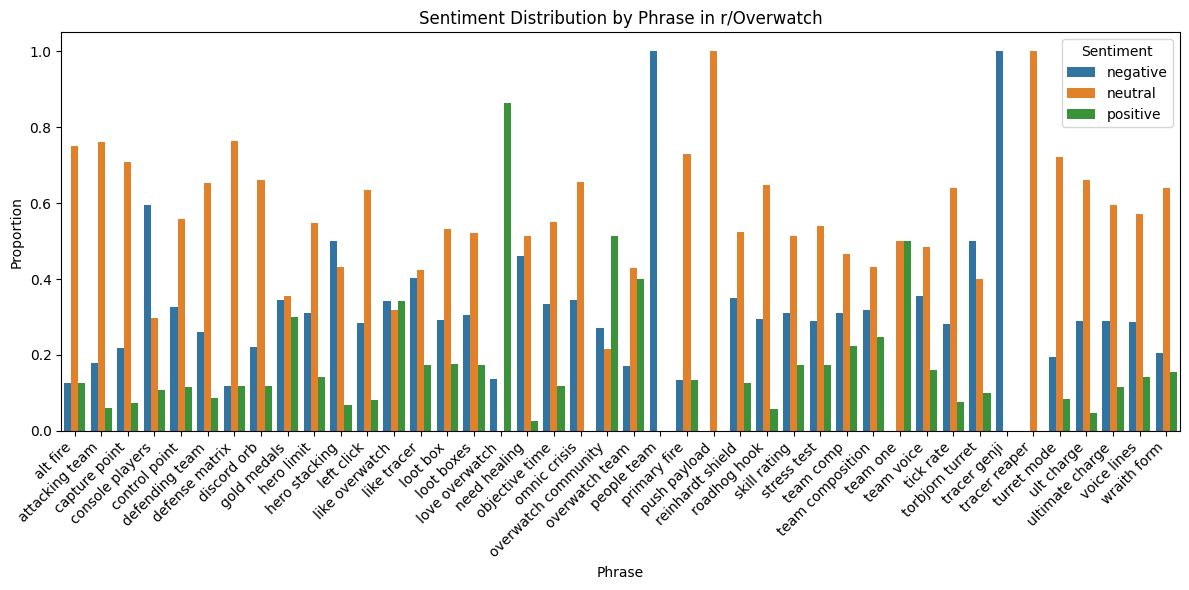

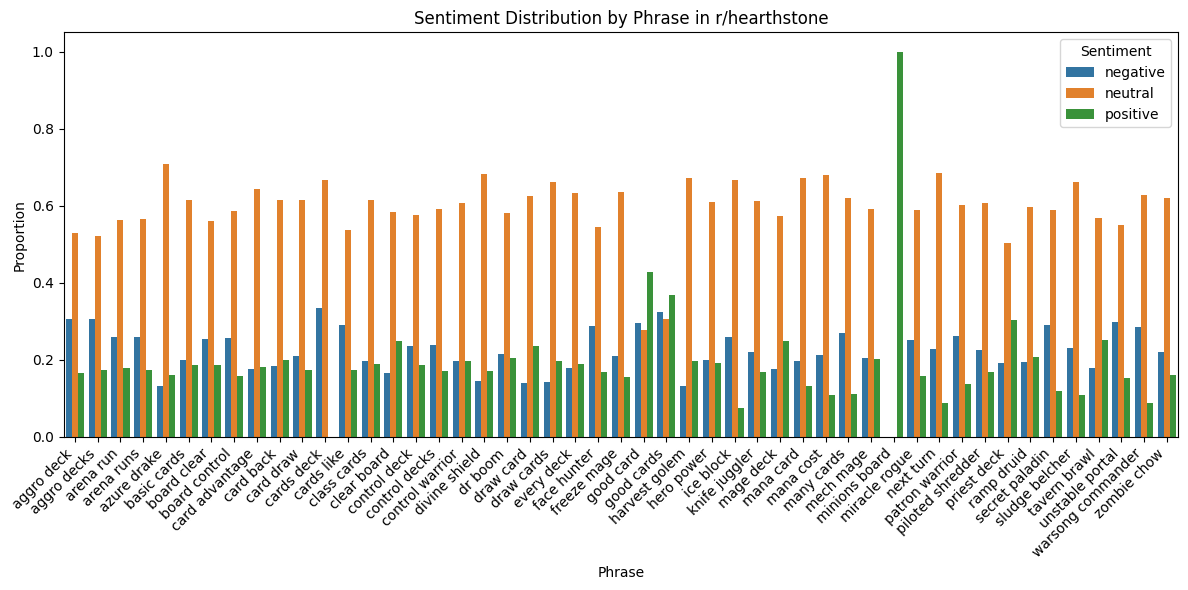

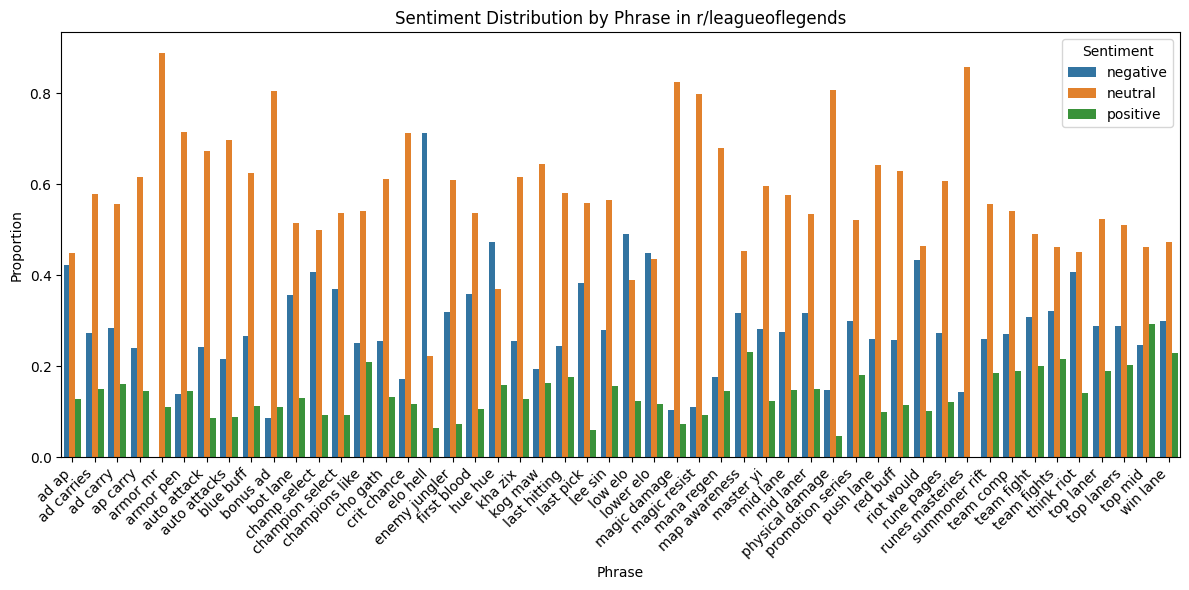

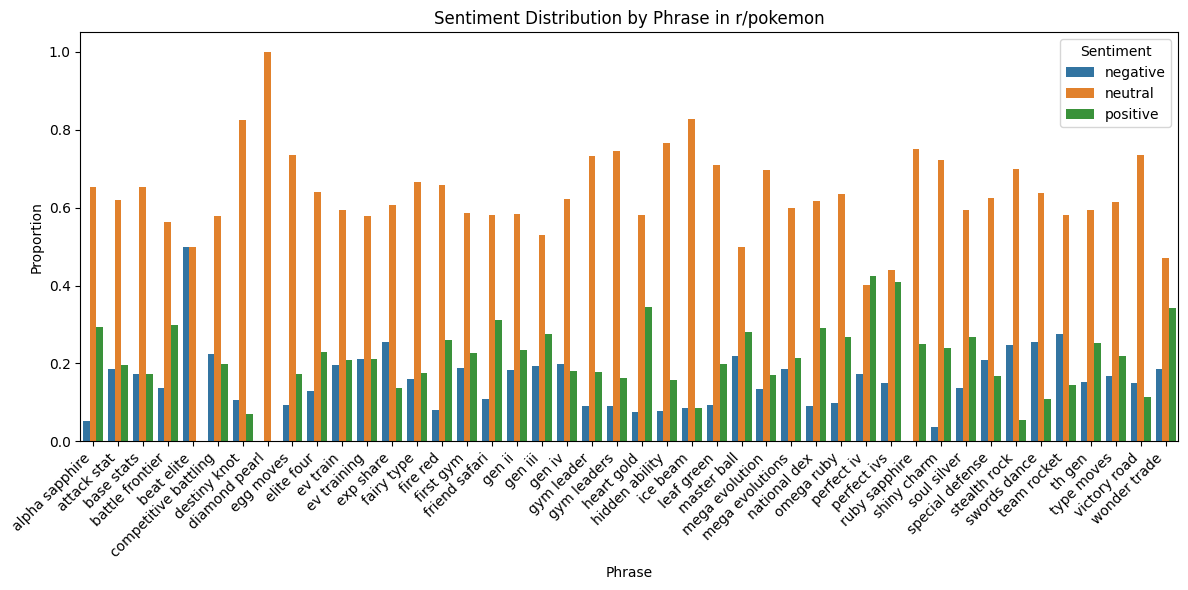

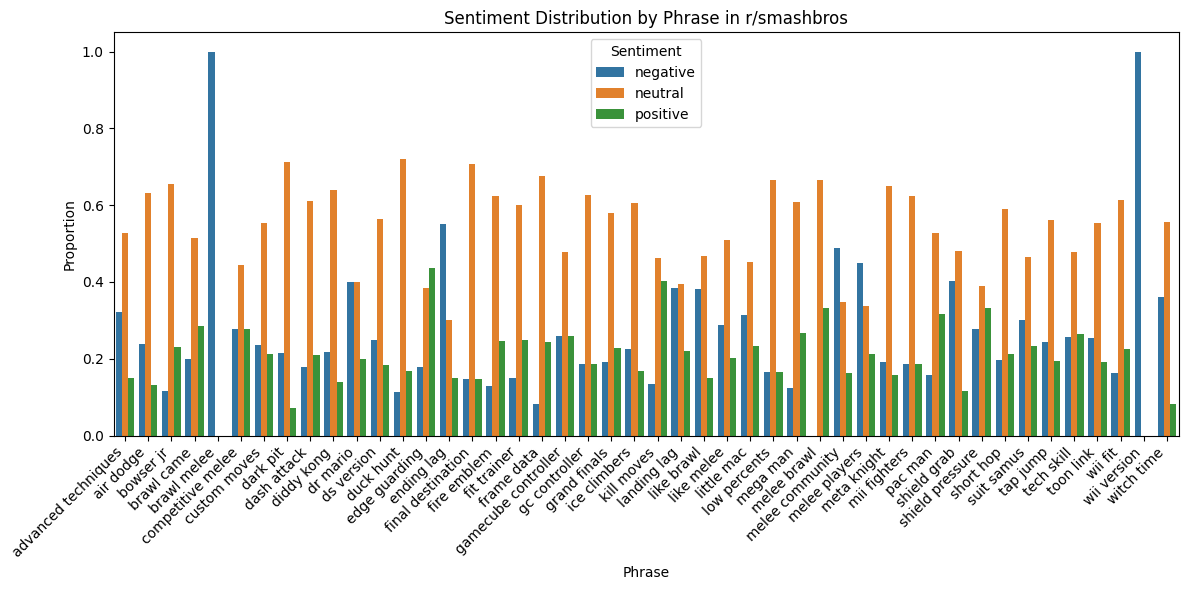

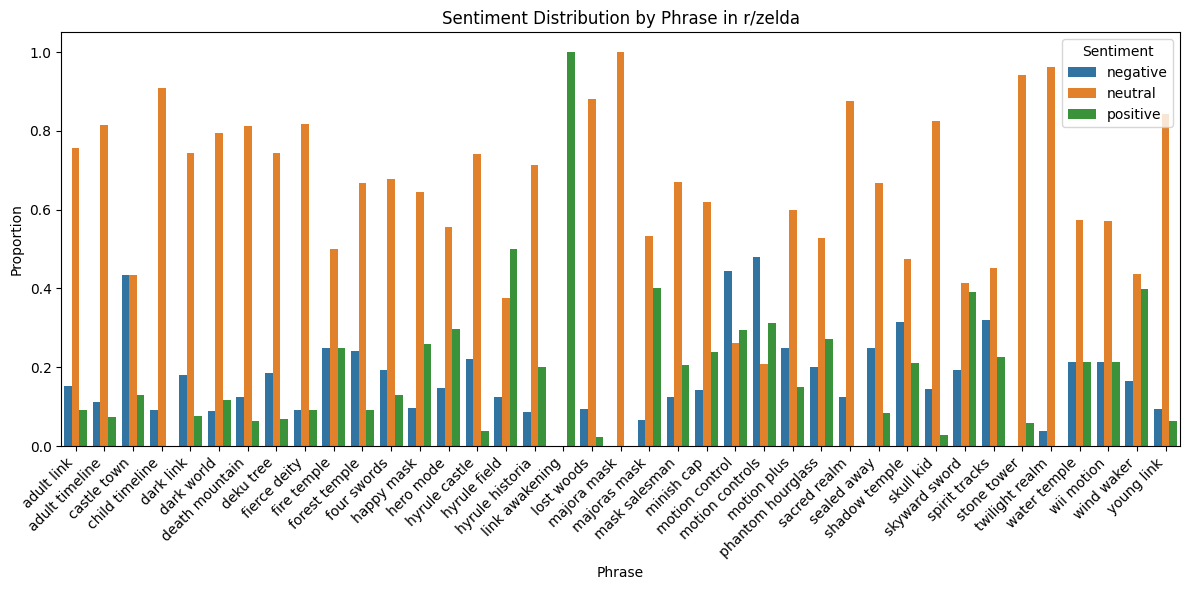

In [33]:
import seaborn as sns
# Choose a subreddit or phrase subset
subreddits = sentiment_summary['subreddit'].unique()

for subreddit in subreddits:
    subset = sentiment_summary[sentiment_summary['subreddit'] == subreddit]
    
    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=subset, 
        x='phrase', 
        y='proportion', 
        hue='senti_label'
    )
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Sentiment Distribution by Phrase in r/{subreddit}')
    plt.ylabel('Proportion')
    plt.xlabel('Phrase')
    plt.legend(title='Sentiment')
    plt.tight_layout()
    plt.show()

In [34]:
# Get phrases with positive sentiment dominance
top_positive = (
    sentiment_summary[sentiment_summary['senti_label'] == 'positive']
    .sort_values(by='proportion', ascending=False)
    .head(20)
)

# Get phrases with negative sentiment dominance
top_negative = (
    sentiment_summary[sentiment_summary['senti_label'] == 'negative']
    .sort_values(by='proportion', ascending=False)
    .head(20)
)

In [35]:
print("Top 20 Positive Phrases by Proportion:")
display(top_positive[['subreddit', 'phrase', 'proportion', 'avg_score']])

print("\nTop 20 Negative Phrases by Proportion:")
display(top_negative[['subreddit', 'phrase', 'proportion', 'avg_score']])

Top 20 Positive Phrases by Proportion:


,subreddit,phrase,proportion,avg_score
718,zelda,link awakening,1.000000,0.819074
222,hearthstone,minions board,1.000000,0.509468
49,Overwatch,love overwatch,0.863636,0.852015
60,Overwatch,overwatch community,0.513514,0.841216
88,Overwatch,team one,0.500000,0.980734
714,zelda,hyrule field,0.500000,0.754940
574,smashbros,edge guarding,0.435897,0.784901
191,hearthstone,good card,0.426710,0.804488
499,pokemon,perfect iv,0.424581,0.718369
502,pokemon,perfect ivs,0.408602,0.712203



Top 20 Negative Phrases by Proportion:


,subreddit,phrase,proportion,avg_score
547,smashbros,brawl melee,1.000000,0.606089
664,smashbros,wii version,1.000000,0.567349
64,Overwatch,people team,1.000000,0.761938
98,Overwatch,tracer genji,1.000000,0.677416
306,leagueoflegends,elo hell,0.712476,0.757885
9,Overwatch,console players,0.594595,0.719417
575,smashbros,ending lag,0.550000,0.714977
419,pokemon,beat elite,0.500000,0.493966
95,Overwatch,torbjorn turret,0.500000,0.698281
30,Overwatch,hero stacking,0.500000,0.656602


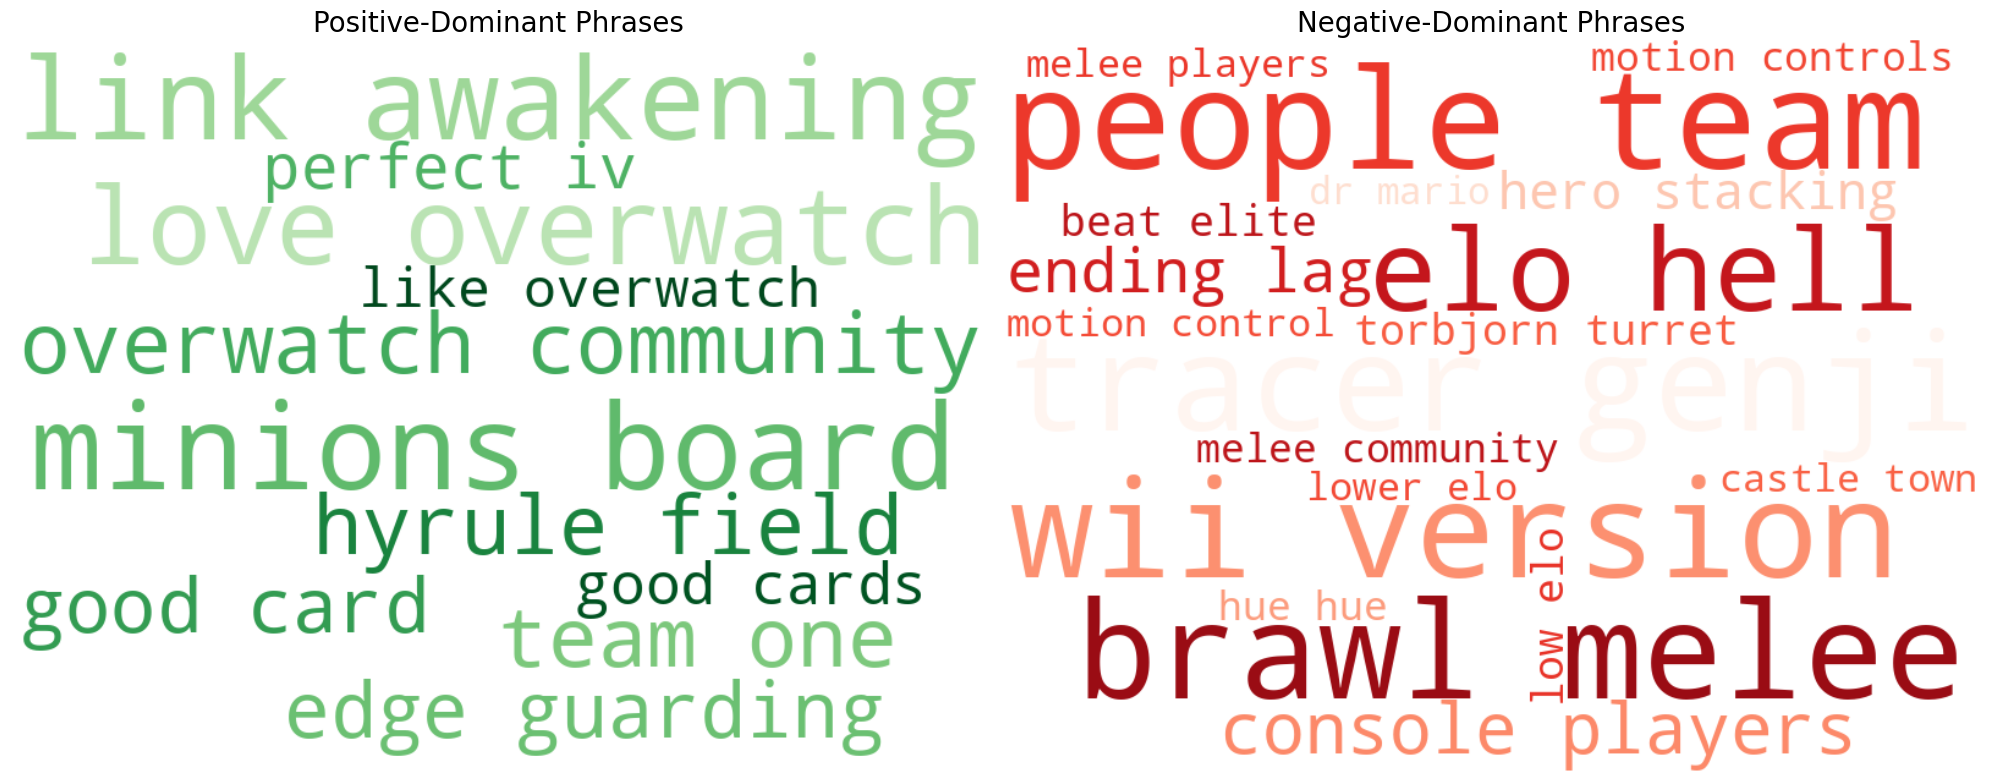

In [36]:
pivot_df = sentiment_summary.pivot_table(
    index=['subreddit', 'phrase'],
    columns='senti_label',
    values='proportion',
    fill_value=0
).reset_index()

# Dominant label
pivot_df['dominant_label'] = pivot_df[['positive', 'negative', 'neutral']].idxmax(axis=1)

# Pozitif dominant
positive_dominant = pivot_df[pivot_df['dominant_label'] == 'positive']
# Negatif dominant
negative_dominant = pivot_df[pivot_df['dominant_label'] == 'negative']

# Phrase -> dict
positive_phrases = dict(zip(positive_dominant['phrase'], positive_dominant['positive']))
negative_phrases = dict(zip(negative_dominant['phrase'], negative_dominant['negative']))

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Pozitif
wordcloud_pos = WordCloud(
    width=800, height=600, background_color='white', colormap='Greens'
).generate_from_frequencies(positive_phrases)

axes[0].imshow(wordcloud_pos, interpolation='bilinear')
axes[0].set_title('Positive-Dominant Phrases', fontsize=20)
axes[0].axis('off')

# Negatif
wordcloud_neg = WordCloud(
    width=800, height=600, background_color='white', colormap='Reds'
).generate_from_frequencies(negative_phrases)

axes[1].imshow(wordcloud_neg, interpolation='bilinear')
axes[1].set_title('Negative-Dominant Phrases', fontsize=20)
axes[1].axis('off')

plt.tight_layout()
plt.show()

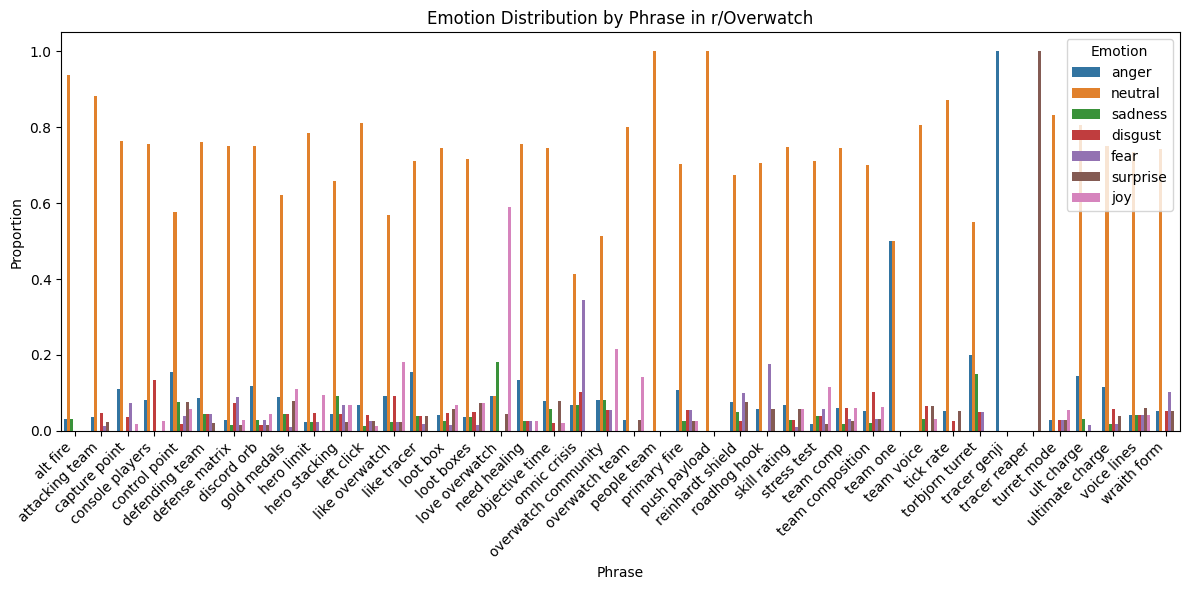

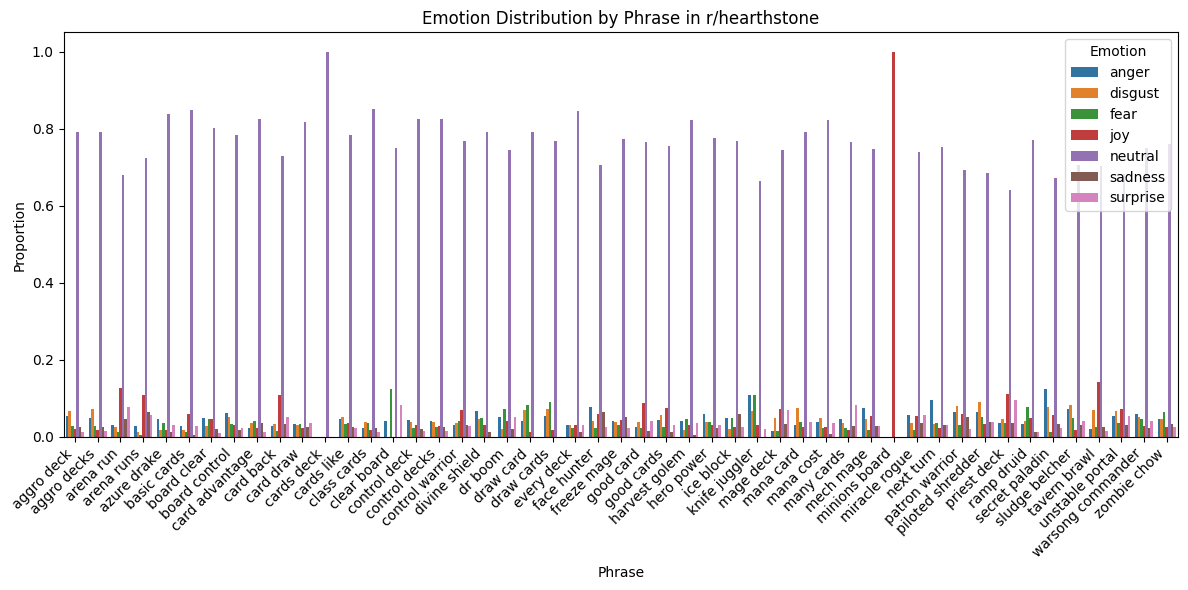

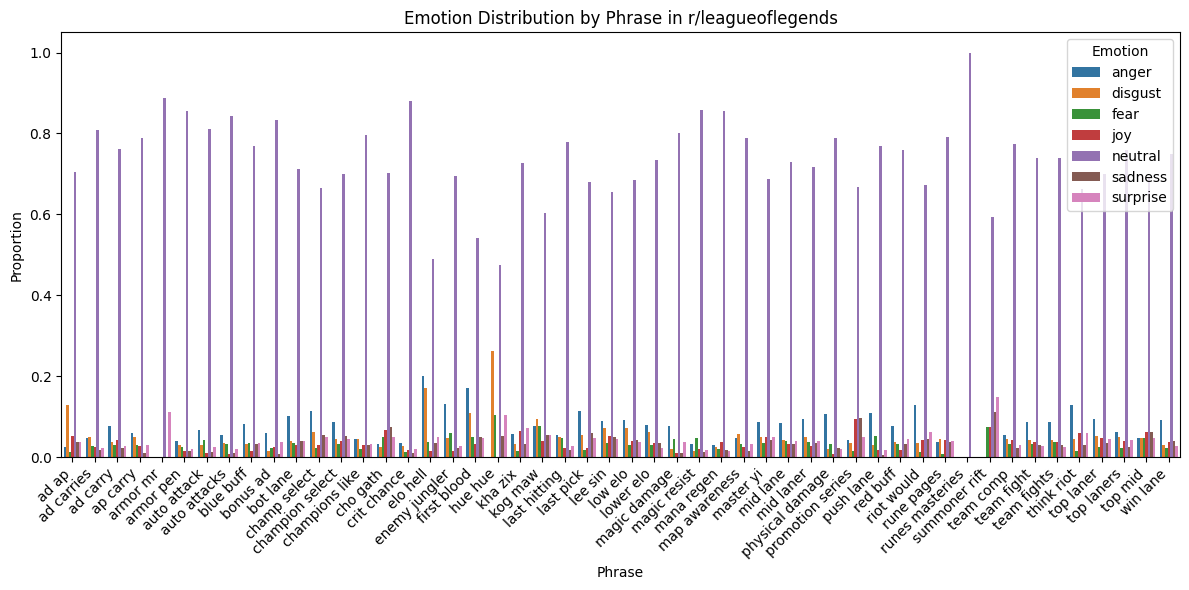

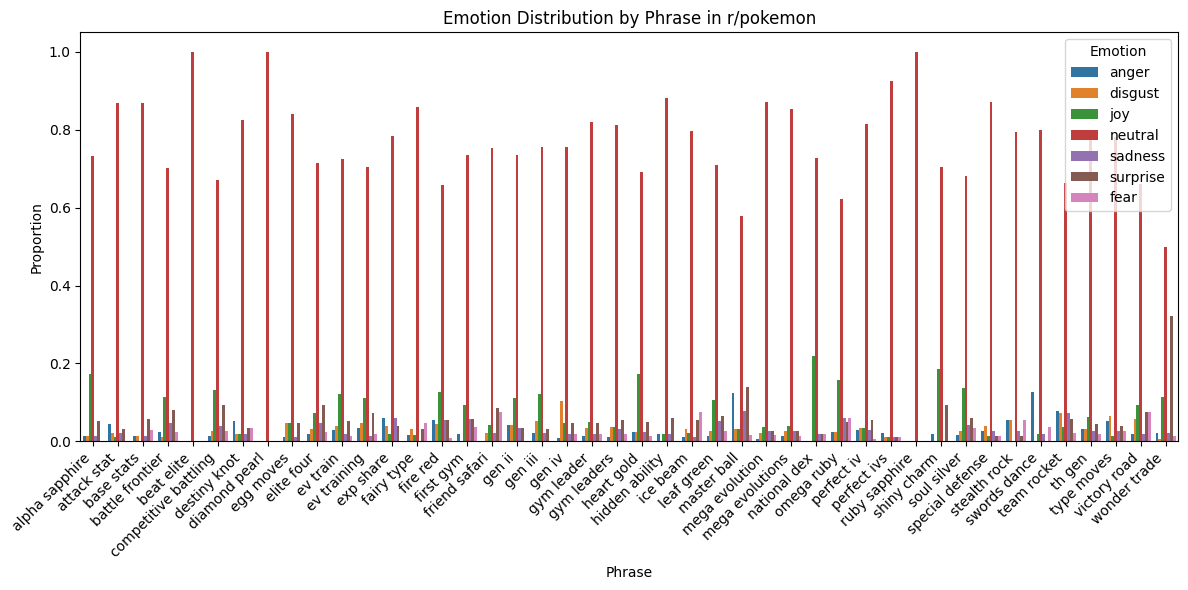

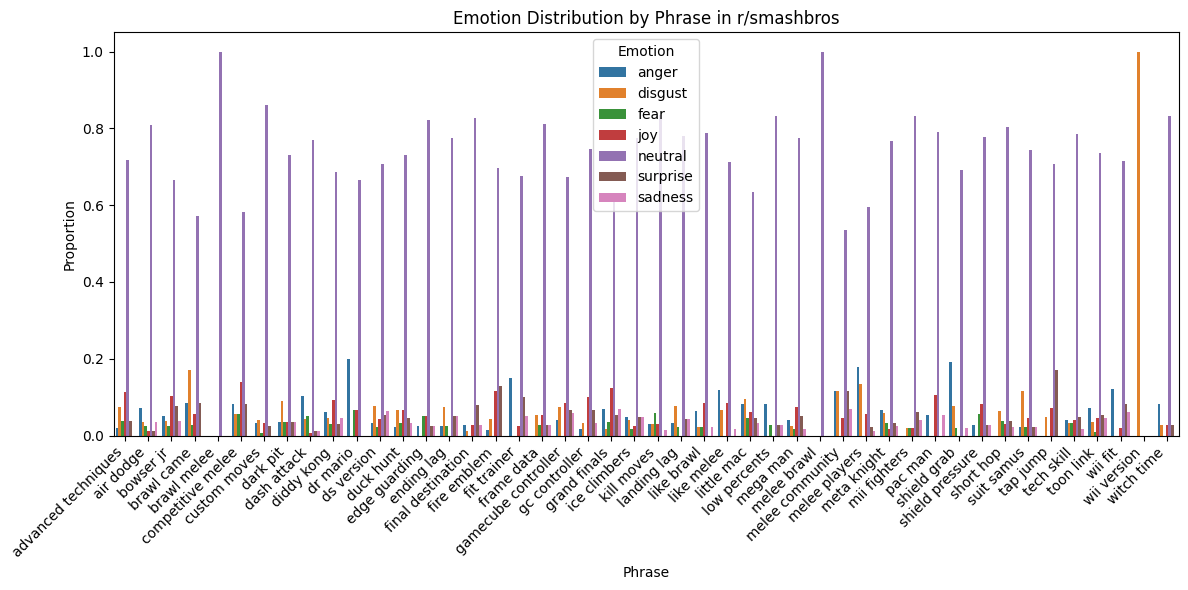

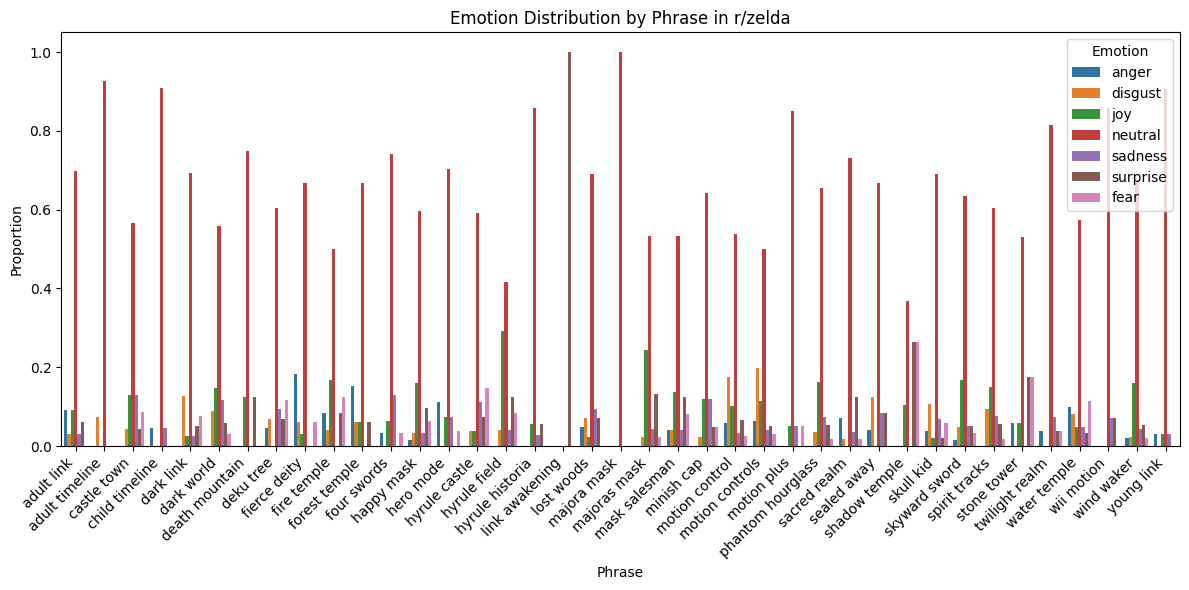

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Aggregate emotion summary (similar to your sentiment_summary)
emotion_summary = (
    phrase_sentiments_df
    .groupby(['subreddit', 'phrase', 'emo_label'])
    .agg(
        count=('emo_label', 'size'),
        avg_score=('emo_score', 'mean')
    )
    .reset_index()
)

# Get total counts per subreddit and phrase
total_counts_emo = (
    phrase_sentiments_df
    .groupby(['subreddit', 'phrase'])
    .size()
    .reset_index(name='total_count')
)

# Merge and compute proportions
emotion_summary = emotion_summary.merge(total_counts_emo, on=['subreddit', 'phrase'])
emotion_summary['proportion'] = emotion_summary['count'] / emotion_summary['total_count']

# Bar plots for emotions
subreddits = emotion_summary['subreddit'].unique()

for subreddit in subreddits:
    subset = emotion_summary[emotion_summary['subreddit'] == subreddit]
    
    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=subset, 
        x='phrase', 
        y='proportion', 
        hue='emo_label'
    )
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Emotion Distribution by Phrase in r/{subreddit}')
    plt.ylabel('Proportion')
    plt.xlabel('Phrase')
    plt.legend(title='Emotion')
    plt.tight_layout()
    plt.show()

In [108]:
# Pivot for dominant emotion per phrase
emotion_pivot_df = emotion_summary.pivot_table(
    index=['subreddit', 'phrase'],
    columns='emo_label',
    values='proportion',
    fill_value=0
).reset_index()

# Find dominant emotion excluding neutral later
emotion_pivot_df['dominant_emotion'] = emotion_pivot_df.loc[:, 
    [col for col in emotion_pivot_df.columns if col not in ['subreddit', 'phrase']]
].idxmax(axis=1)

# Exclude neutral dominant phrases
non_neutral_emotion_phrases = emotion_pivot_df[emotion_pivot_df['dominant_emotion'] != 'neutral']

print(non_neutral_emotion_phrases[['subreddit', 'phrase', 'dominant_emotion']].head(20))

emo_label    subreddit          phrase dominant_emotion
16           Overwatch  love overwatch              joy
31           Overwatch        team one            anger
35           Overwatch    tracer genji            anger
36           Overwatch   tracer reaper         surprise
78         hearthstone   minions board              joy
229          smashbros     wii version          disgust
248              zelda  link awakening         surprise


In [109]:
def get_second_dominant(row):
    # Select only emotion columns (should be all floats)
    emotions = row[emotion_cols]

    # Sort descending
    sorted_emotions = emotions.sort_values(ascending=False)

    # Filter out zero or very small values (avoid meaningless seconds)
    filtered = sorted_emotions[sorted_emotions > 0]

    if len(filtered) < 2:
        return None  # no valid second dominant

    return filtered.index[1]  # second highest emotion label

In [110]:
emotion_pivot_df['second_dominant_emotion'] = emotion_pivot_df.apply(get_second_dominant, axis=1)

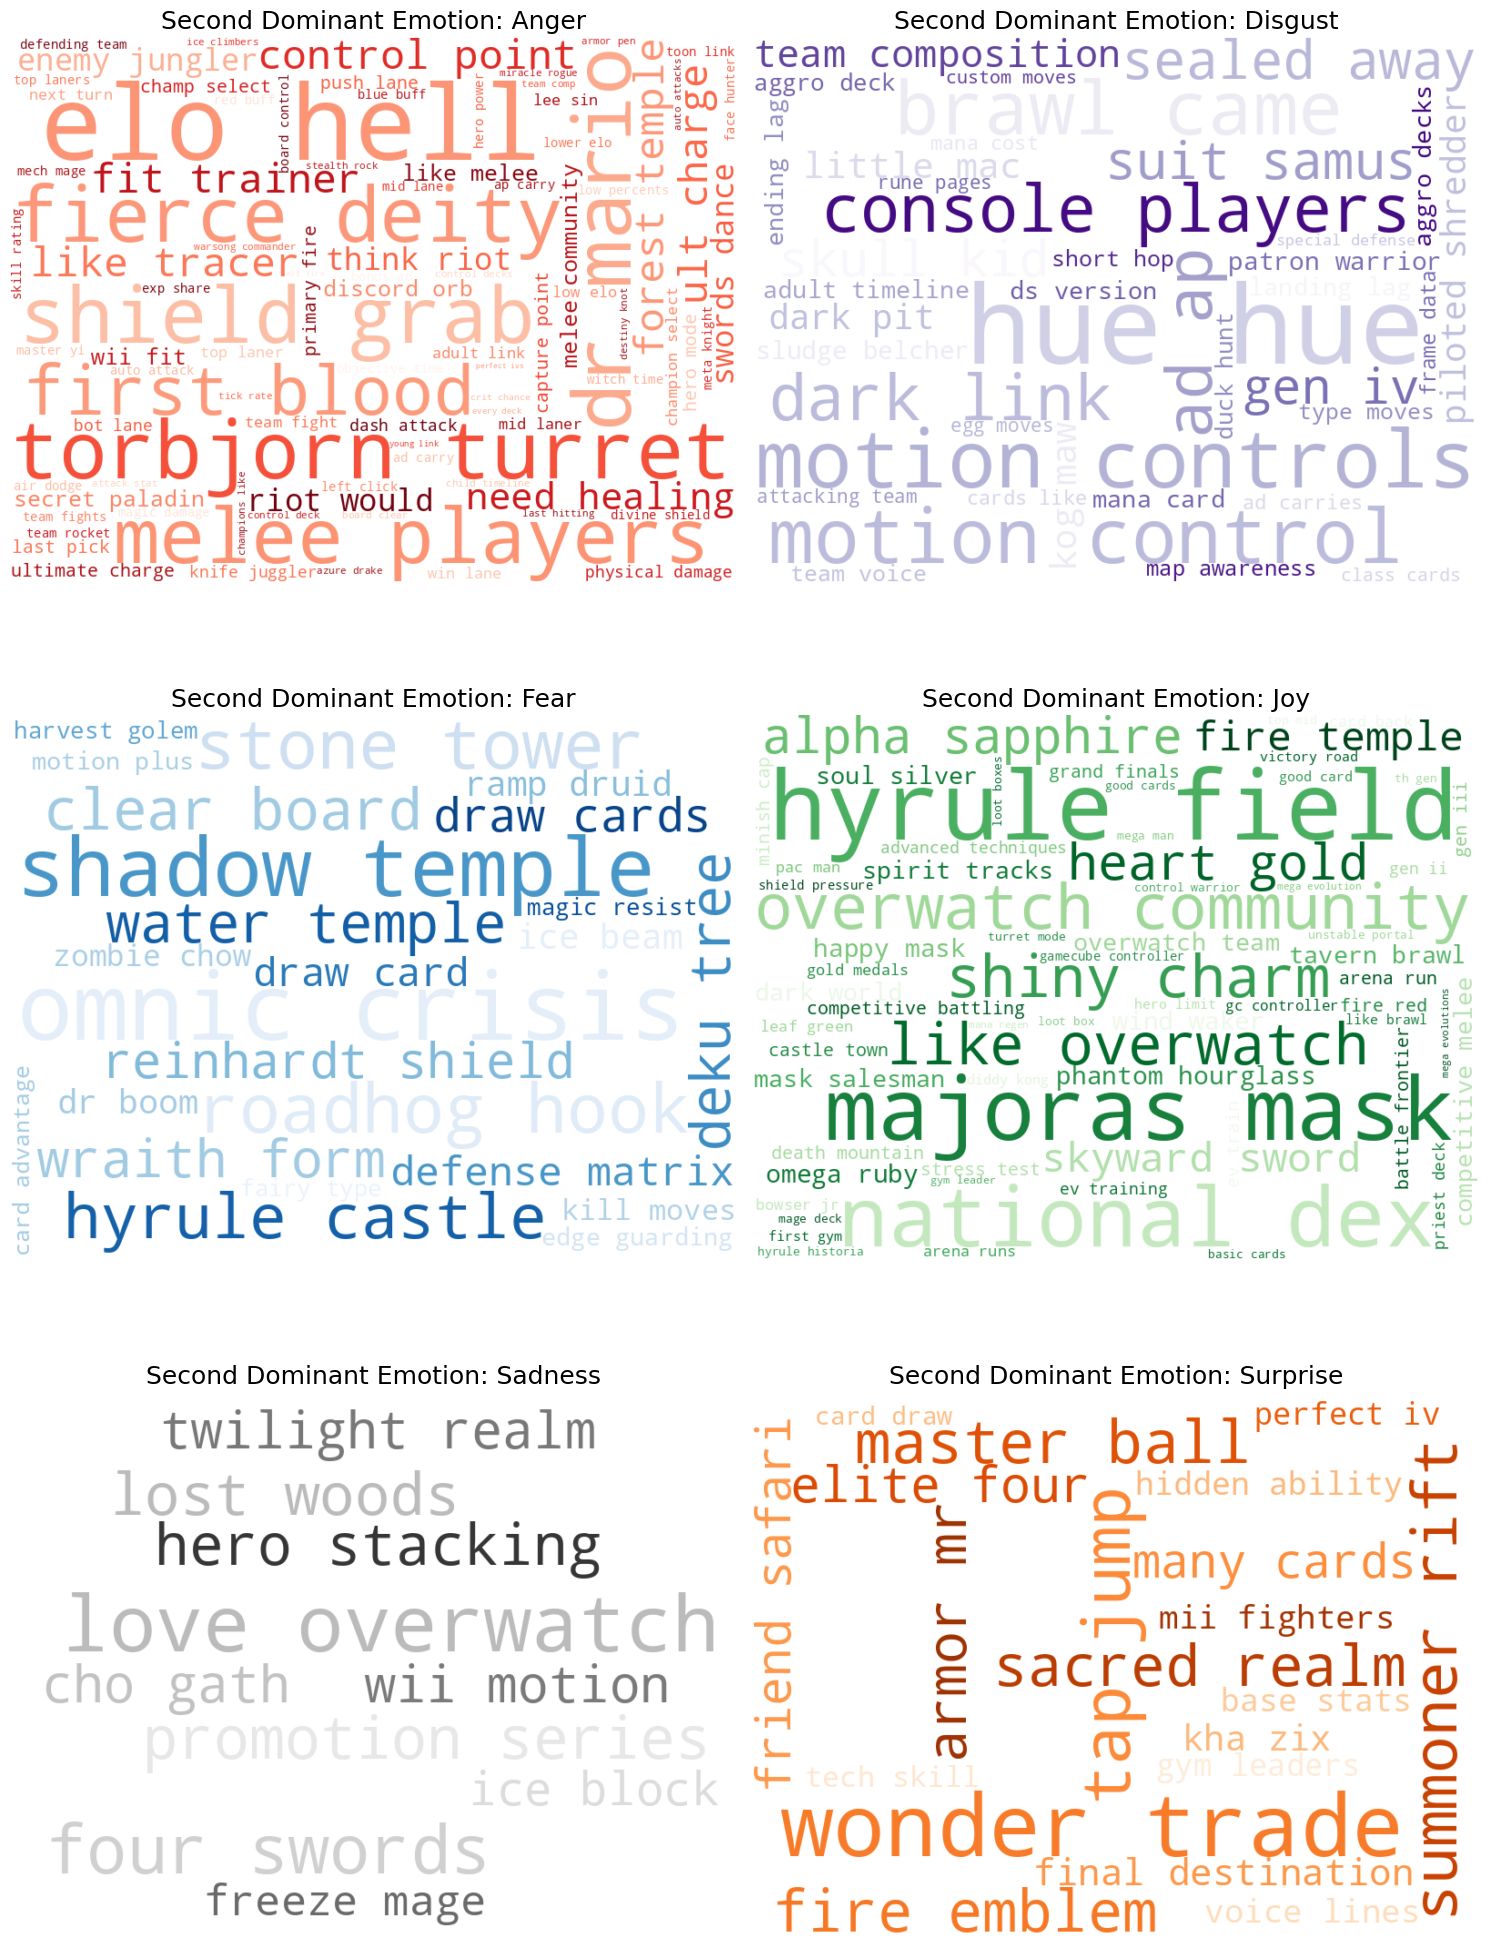

In [111]:
# Define your emotions and their corresponding colormaps
emotion_colormaps = {
    'anger': 'Reds',
    'disgust': 'Purples',
    'fear': 'Blues',
    'joy': 'Greens',
    'sadness': 'Greys',
    'surprise': 'Oranges',
    # 'neutral' intentionally excluded if you want to skip it
}

# Filter emotion columns (exclude meta columns)
emotion_cols = [col for col in emotion_pivot_df.columns if col not in ['subreddit', 'phrase', 'dominant_emotion', 'second_dominant_emotion']]

# Keep only emotions in your colormap dict and second dominant emotion
emotions_to_plot = [e for e in emotion_cols if e in emotion_colormaps]

# Set up the grid size for subplots dynamically (e.g., 2 cols)
cols = 2
rows = (len(emotions_to_plot) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, 7*rows))
axes = axes.flatten()

for i, emotion in enumerate(emotions_to_plot):
    # Get phrases where second dominant emotion is this emotion
    filtered_phrases = emotion_pivot_df[emotion_pivot_df['second_dominant_emotion'] == emotion]
    
    if filtered_phrases.empty:
        axes[i].axis('off')
        axes[i].set_title(f'No data for {emotion}')
        continue
    
    freq_dict = dict(zip(filtered_phrases['phrase'], filtered_phrases[emotion]))
    
    wordcloud = WordCloud(
        width=800, height=600,
        background_color='white',
        colormap=emotion_colormaps[emotion]
    ).generate_from_frequencies(freq_dict)
    
    axes[i].imshow(wordcloud, interpolation='bilinear')
    axes[i].set_title(f'Second Dominant Emotion: {emotion.capitalize()}', fontsize=18)
    axes[i].axis('off')

# Turn off any unused axes if total emotions < rows*cols
for j in range(i+1, rows*cols):
    axes[j].axis('off')

plt.tight_layout()
plt.show()
